In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import re
import os

In [13]:
df = pd.read_csv(r'D:\IT\Python\sklearn\hotel-booking-project\data\hotel_bookings.csv')
pd.set_option('display.max_columns', None)

In [14]:
df.head(3)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


In [9]:
pd.crosstab(df["hotel"], df["is_canceled"])

is_canceled,0,1
hotel,,
City Hotel,46228,33102
Resort Hotel,28938,11122


<Axes: xlabel='is_canceled'>

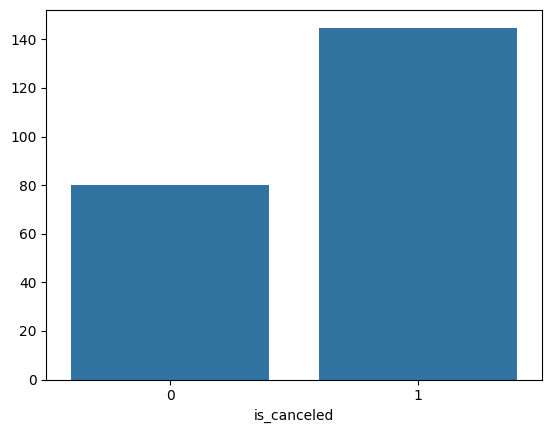

In [10]:
lead = df.groupby('is_canceled')['lead_time'].mean()
sns.barplot(x=lead.index, y=lead.values)

In [15]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

In [17]:
num_cols = [
    "lead_time",
    "adr",
    "booking_changes",
    "days_in_waiting_list"
]

is_canceled
0     99.987693
1    104.964333
Name: adr, dtype: float64

In [20]:
c = df.groupby("is_canceled")
print(c['adr'].mean())
print(c['booking_changes'].mean())
print(c['days_in_waiting_list'].mean())

is_canceled
0     99.987693
1    104.964333
Name: adr, dtype: float64
is_canceled
0    0.293364
1    0.098340
Name: booking_changes, dtype: float64
is_canceled
0    1.589868
1    3.564083
Name: days_in_waiting_list, dtype: float64


In [31]:
p = df.groupby('country')['is_canceled'].mean().sort_values(ascending=False).head(20)

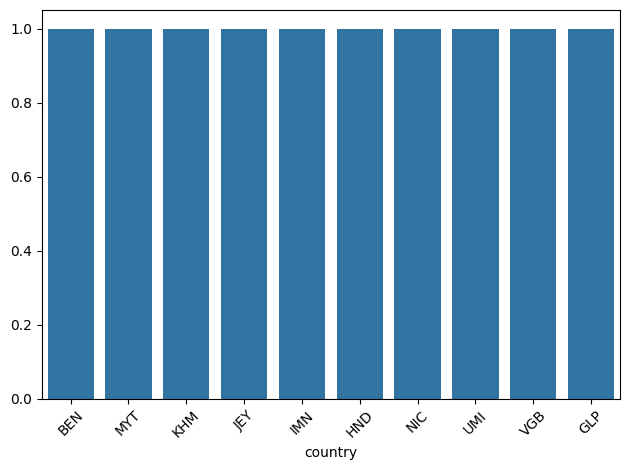

In [35]:
sns.barplot(x = p.index, y = p.values)
plt.xticks(rotation=45)
plt.tight_layout()

In [36]:
pd.crosstab(
    df["deposit_type"],
    df["is_canceled"],
    normalize="index"
)

is_canceled,0,1
deposit_type,,
No Deposit,0.716230,0.283770
Non Refund,0.006376,0.993624
Refundable,0.777778,0.222222


In [37]:
pd.crosstab(
    df["market_segment"],
    df["is_canceled"],
    normalize="index"
)

is_canceled,0,1
market_segment,,
Aviation,0.780591,0.219409
Complementary,0.869448,0.130552
Corporate,0.812653,0.187347
Direct,0.846581,0.153419
Groups,0.389380,0.610620
Offline TA/TO,0.656840,0.343160
Online TA,0.632789,0.367211
Undefined,0.000000,1.000000


In [38]:
pd.crosstab(
    df["customer_type"],
    df["is_canceled"],
    normalize="index"
)

is_canceled,0,1
customer_type,,
Contract,0.690383,0.309617
Group,0.897747,0.102253
Transient,0.592537,0.407463
Transient-Party,0.745701,0.254299


In [39]:
pd.crosstab(
    df["distribution_channel"],
    df["is_canceled"],
    normalize="index"
)

is_canceled,0,1
distribution_channel,,
Corporate,0.779242,0.220758
Direct,0.825401,0.174599
GDS,0.808290,0.191710
TA/TO,0.589741,0.410259
Undefined,0.200000,0.800000
